In [1]:
import numpy as np
import jax
import pandas as pd
from scipy.stats import norm, halfnorm
import matplotlib.pyplot as plt
import seaborn as sns

# Assurez-vous que la librairie pyhgf est accessible
from pyhgf.model import Network

# Imports depuis notre projet
from simulation import Simulation
from strategies.decision.hgf_strategy import HGFDecisionStrategy
from strategies.voting.two_round_system import TwoRoundSystem
from analysis.plotting import plot_winner_distribution, plot_round_1_proportions

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
SIM_PARAMS = {
    "n_simulations": 50,
    "n_agents": 100,
    "n_candidates": 6,
    "n_preferences": 4,
}

# Clé JAX principale pour la reproductibilité
key = jax.random.PRNGKey(42)

In [3]:
# 3.1. Données d'observation
def generate_observations(n_nodes, n_steps, scenario=1):
    return np.random.randint(2, size=(n_steps, n_nodes)).astype(np.float64)


input_data = generate_observations(SIM_PARAMS["n_preferences"], n_steps=100, scenario=1)

# 3.2. Réseau HGF de base
base_network = Network()
base_network.add_nodes(kind="binary-state", n_nodes=SIM_PARAMS["n_preferences"])
for i in range(SIM_PARAMS["n_preferences"]):
    base_network.add_nodes(value_children=i)

# 3.3. Génération des candidats
candidates = []
for i in range(SIM_PARAMS["n_candidates"]):
    preferences = tuple(
        (norm.rvs(loc=2, scale=1), halfnorm.rvs(scale=1))
        for _ in range(SIM_PARAMS["n_preferences"])
    )
    candidates.append(preferences)

# 3.4. Génération des paramètres des agents
agent_params = []
tonic_volatilities = np.random.normal(loc=-3.0, scale=1.0, size=SIM_PARAMS["n_agents"])
for i in range(SIM_PARAMS["n_agents"]):
    agent_prefs = tuple(
        (norm.rvs(loc=2, scale=1), halfnorm.rvs(scale=1))
        for _ in range(SIM_PARAMS["n_preferences"])
    )
    agent_params.append(
        {"preferences": agent_prefs, "tonic_volatility": tonic_volatilities[i]}
    )

In [4]:
# 4.1. Instanciation des stratégies
hgf_strategy = HGFDecisionStrategy()
two_round_voting = TwoRoundSystem()

# 4.2. Création de l'objet Simulation principal
sim = Simulation(
    sim_params=SIM_PARAMS,
    agent_params=agent_params,
    candidates=candidates,
    base_hgf_network=base_network,
    decision_strategy=hgf_strategy,
    voting_system=two_round_voting,
    input_data=input_data,
)

# 4.3. Lancement !
results_df = sim.run(key)

Running the initial learning phase for all agents...


Agent Learning: 100%|██████████| 100/100 [01:04<00:00,  1.56it/s]


Learning phase complete.


Simulations: 100%|██████████| 50/50 [00:02<00:00, 22.94it/s]
/Users/sylvainestebe/Code/european-city-inference/src/data_collector.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return pd.DataFrame(self.results).fillna(0)


Simulation terminée. Affichage des 10 premiers résultats :


,simulation_number,winner_index,finalists,r1_prop_cand_0,r1_prop_cand_1,r1_prop_cand_2,r1_prop_cand_3,r1_prop_cand_4,r1_prop_cand_5
0,1,0,0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,0,0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,0,0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,0,0,1.0,0.0,0.0,0.0,0.0,0.0
5,6,0,0,1.0,0.0,0.0,0.0,0.0,0.0
6,7,0,0,1.0,0.0,0.0,0.0,0.0,0.0
7,8,0,0,1.0,0.0,0.0,0.0,0.0,0.0
8,9,0,0,1.0,0.0,0.0,0.0,0.0,0.0
9,10,0,0,1.0,0.0,0.0,0.0,0.0,0.0


/Users/sylvainestebe/Code/european-city-inference/src/analysis/plotting.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='winner_index', order=df['winner_index'].value_counts().index, palette="viridis")


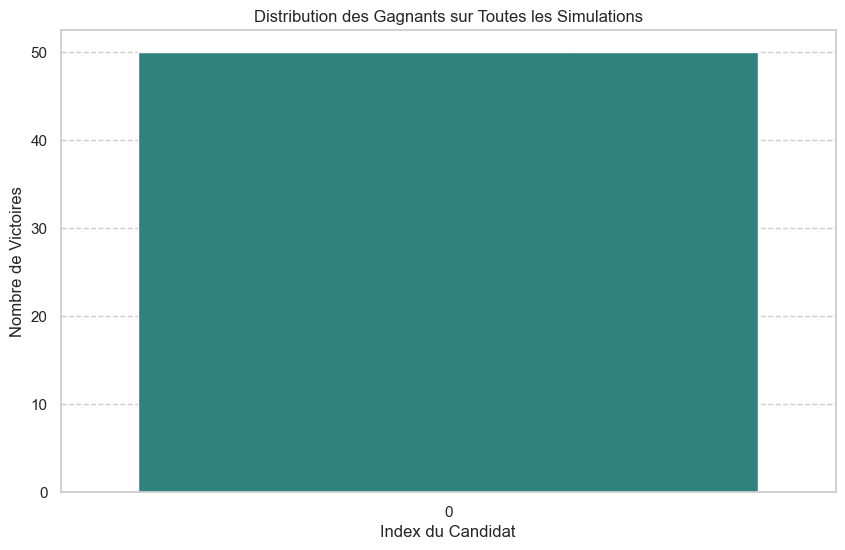

/Users/sylvainestebe/Code/european-city-inference/src/analysis/plotting.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=r1_df, x='Candidate', y='Average Proportion', palette="mako")


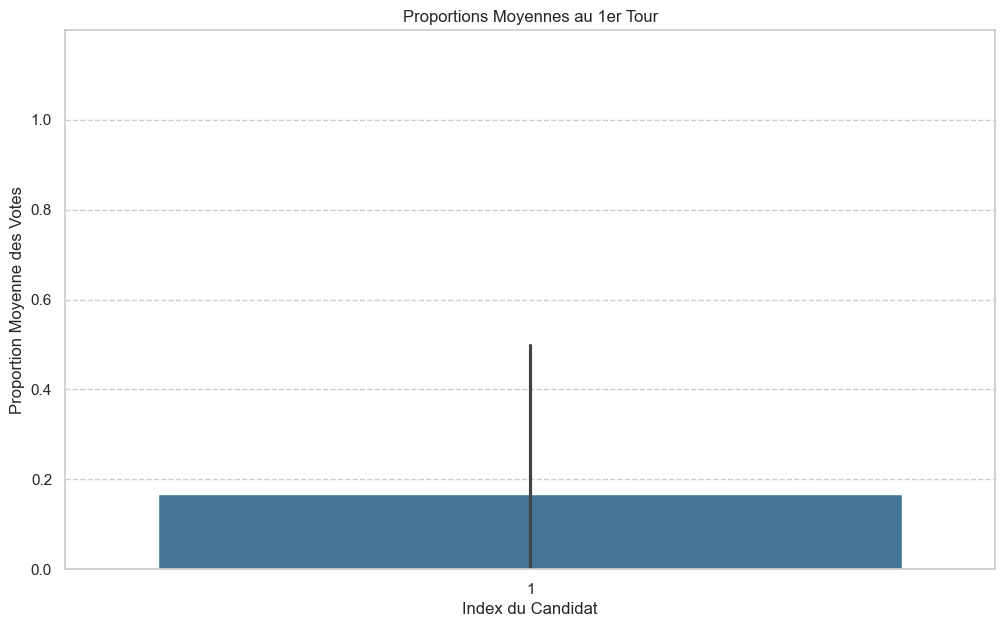

In [6]:
print("Simulation terminée. Affichage des 10 premiers résultats :")
display(results_df.head(10))

plot_winner_distribution(results_df)
plot_round_1_proportions(results_df)